# Seminar Project I: Computer Signal Processing (KI/PZS)
**Author:** Aleksandr Demin (F24343)
**Institution:** Jan Evangelista Purkyně University (UJEP)

---


## Part 1: Heart Rate Estimation from ECG Signals


### 1. Library Imports


In [1]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.signal as signal


### 2. Data Loading & Signal Inspection
Loading the raw ECG signal from the *Stress Recognition in Automobile Drivers* database (`drivedb/1.0.0`).


In [2]:
import os
# Locate data directory
data_candidates = [
    "../../data/stress-recognition-in-automobile-drivers-1.0.0/stress-recognition-in-automobile-drivers-1.0.0",
    "../data/stress-recognition-in-automobile-drivers-1.0.0/stress-recognition-in-automobile-drivers-1.0.0",
    r"C:\Users\alecs\My Drive\UJEP\PZS\SemPrace1\data\stress-recognition-in-automobile-drivers-1.0.0\stress-recognition-in-automobile-drivers-1.0.0"
]
file_path = next((p for p in data_candidates if os.path.exists(p)), data_candidates[-1])
data = wfdb.rdrecord(file_path + "\\drive01")
ecg_signal = data.p_signal[:, 0]
sampling_rate = data.fs
print("Channels:", getattr(data, "sig_name", None))
print("Sampling frequency:", data.fs)


Channels: ['ECG', 'EMG', 'foot GSR', 'hand GSR', 'HR', 'RESP']
Sampling frequency: 15.5


We select the first channel (`ECG`) for R-peak extraction and cardiac rhythm analysis.


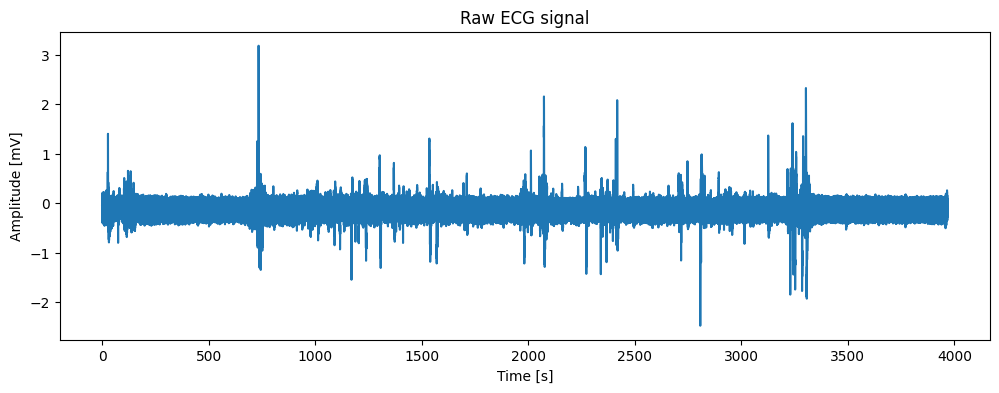

Sampling frequency: 15.5 Hz
Signal length: 3967.68 seconds


In [3]:
plt.figure(figsize=(12, 4))
plt.plot(np.arange(len(ecg_signal))/sampling_rate, ecg_signal)
plt.title("Raw ECG signal")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude [mV]")
plt.show()


print(f"Sampling frequency: {sampling_rate} Hz")
print(f"Signal length: {len(ecg_signal)/sampling_rate:.2f} seconds")

### 3. R-Peak Detection Algorithm Design


The `detect_r_peaks` function automates R-peak fiducial point localization in single-lead ECG.

#### Operational Principles:
1. **Z-Score Normalization:** Standardizes the ECG waveform ($z = (x - \mu)/\sigma$) to ensure gain invariance.
2. **Adaptive Refractory Period:** Suppresses secondary peaks within biologically implausible refractory intervals ($d_{\text{min}} = 0.30\text{ s}$, corresponding to $\le 200\text{ BPM}$).
3. **Prominence & Thresholding:** Detects local maxima using `scipy.signal.find_peaks` with prominence filtering to reject noise and high-frequency baseline artifacts.
4. **Sample Index Output:** Returns indices of localized R-peaks.


In [4]:
def detect_r_peaks(
    ecg_signal,
    sampling_rate,
    min_rr_sec=0.30,        # minimal RR interval (~200 bpm max)
    height_scale=0.0,       # threshold = mean + height_scale*std; 0 for very permissive
    prominence=0.5          # basic prominence to reduce tiny noise peaks
):

    x = np.asarray(ecg_signal, float)
    fs = float(sampling_rate)
    if x.size == 0 or fs <= 0:
        return np.array([], dtype=int), {"error": "empty signal or invalid sampling_rate"}

    # Z-score normalize
    xz = (x - np.mean(x)) / (np.std(x) + 1e-12)

    # Simple peak picking
    distance = max(1, int(min_rr_sec * fs)) # ensure at least min_rr_sec between peaks
    height = np.mean(xz) + height_scale * np.std(xz) # threshold height

    peaks, props = signal.find_peaks(
        xz,
        height=height,
        distance=distance,
        prominence=prominence
    )

    return peaks.astype(int)

### 3.1 Instantaneous Heart Rate Calculation
Computes beat-to-beat intervals (RR intervals) and instantaneous BPM values.


In [5]:
def compute_heart_rate(r_peaks_idx, sampling_rate):
    """
    Compute instantaneous heart rate (bpm) from R-peaks.

    Returns:
      hr_bpm: array of instantaneous BPM (beat-to-beat)
      hr_times_s: time positions (s) associated with hr_bpm (midpoints between beats)
      mean_bpm: scalar average BPM (np.nan if insufficient beats)
    """
    r_peaks_idx = np.asarray(r_peaks_idx, dtype=int) 
    fs = float(sampling_rate)

    # if r_peaks_idx.size < 2: 
    #     return np.array([]), np.array([]), np.nan

    r_times = r_peaks_idx / fs
    rr = np.diff(r_times)  # seconds
    # Filter out absurd intervals (optional simple sanity)
    valid = (rr > 0.3) & (rr < 2.1)  # 30–210 bpm range
    rr_valid = rr[valid]
    times_valid = (r_times[1:] + r_times[:-1]) / 2.0
    times_valid = times_valid[valid]

    # if rr_valid.size == 0: 
    #     return np.array([]), np.array([]), np.nan 

    hr_bpm = 60.0 / rr_valid
    mean_bpm = float(np.mean(hr_bpm)) if hr_bpm.size else np.nan
    return hr_bpm, times_valid, mean_bpm

### 3.2 High-Level Processing Wrapper
Convenience wrapper executing detection and heart rate derivation.


In [6]:
def process_ecg(ecg_signal, sampling_rate):
    """
    Convenience wrapper: detect peaks and compute HR.
    Returns:
      r_peaks_idx, hr_times_s, hr_bpm, mean_bpm
    """
    r_peaks = detect_r_peaks(ecg_signal, sampling_rate)
    hr_bpm, hr_times_s, mean_bpm = compute_heart_rate(r_peaks, sampling_rate)
    return r_peaks, hr_times_s, hr_bpm, mean_bpm

### 4. Algorithmic Visualization & Inspection


Detected 5047 R-peaks, Mean HR: 87.26 bpm


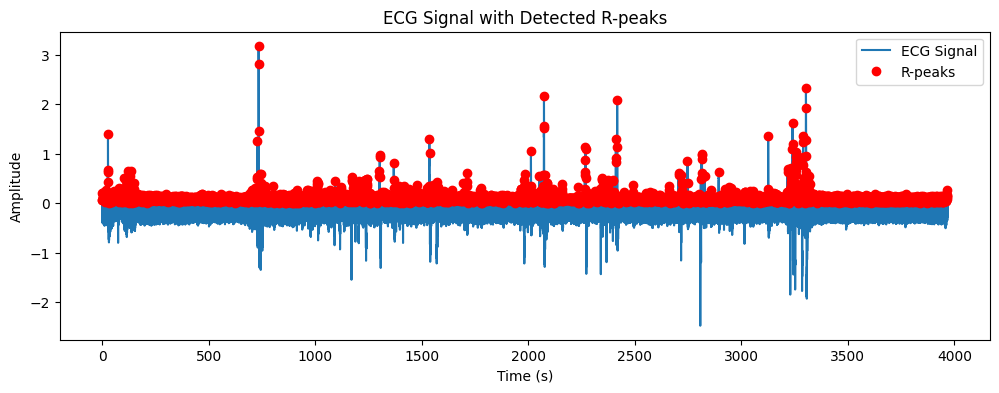

In [7]:
r_peaks, hr_times_s, hr_bpm, mean_bpm = process_ecg(ecg_signal, sampling_rate)
print(f"Detected {len(r_peaks)} R-peaks, Mean HR: {mean_bpm:.2f} bpm")
plt.figure(figsize=(12, 4))
plt.plot(np.arange(len(ecg_signal))/sampling_rate, ecg_signal, label="ECG Signal")
plt.plot(r_peaks/sampling_rate, ecg_signal[r_peaks], 'ro', label="R-peaks")
plt.title("ECG Signal with Detected R-peaks")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

### 4.1 Detailed 60-Second Magnified Window


Detected 5047 R-peaks, Mean HR: 87.26 bpm


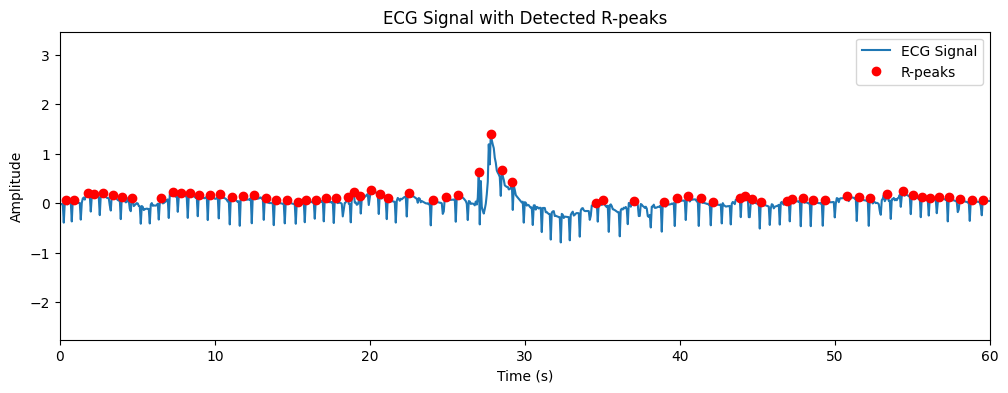

In [8]:
print(f"Detected {len(r_peaks)} R-peaks, Mean HR: {mean_bpm:.2f} bpm")
plt.figure(figsize=(12, 4))
plt.plot(np.arange(len(ecg_signal))/sampling_rate, ecg_signal, label="ECG Signal")
plt.plot(r_peaks/sampling_rate, ecg_signal[r_peaks], 'ro', label="R-peaks")
plt.xlim(0, 60)  # Zoom into first 60 seconds
plt.title("ECG Signal with Detected R-peaks")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

### 4.2 Result Analysis & Discussion
As observed in the magnified window, the detector accurately tracks R-peaks during stationary baseline periods. However, during non-stationary baseline wandering or rapid negative signal drift, static global thresholds may occasionally miss peaks or misclassify elevated T-waves. Preprocessing with bandpass filtering (0.5–40 Hz) is recommended for clinical deployments.


### 5. Quantitative Benchmark on MIT-BIH Normal Sinus Rhythm Database (`nsrdb/1.0.0`)
We benchmark the detector across all 18 annotated Holter records from the MIT-BIH Normal Sinus Rhythm Database.


In [9]:
import os
data_candidates = [
    "../../data/mit-bih-normal-sinus-rhythm-database-1.0.0/mit-bih-normal-sinus-rhythm-database-1.0.0",
    "../data/mit-bih-normal-sinus-rhythm-database-1.0.0/mit-bih-normal-sinus-rhythm-database-1.0.0",
    r"C:\Users\alecs\My Drive\UJEP\PZS\SemPrace1\data\mit-bih-normal-sinus-rhythm-database-1.0.0\mit-bih-normal-sinus-rhythm-database-1.0.0"
]
file_path = next((p for p in data_candidates if os.path.exists(p)), data_candidates[-1])
record = wfdb.rdrecord(file_path + '\\16265')
ann = wfdb.rdann(file_path + '\\16265', 'atr')
ecg = record.p_signal[:, 0]
fs = record.fs
reference = ann.sample # R-peak annotations
r_peaks, hr_times_s, hr_bpm, mean_bpm = process_ecg(ecg, fs)
hr_actual = len(reference) / (len(ecg)/fs / 60)
hr_detected = len(r_peaks) / (len(ecg)/fs / 60)
accuracy = 100 - (abs(hr_actual - hr_detected) / hr_actual * 100)
print(f"Actual heart rate: {hr_actual:.1f} bpm")
print(f"Detected heart rate: {hr_detected:.1f} bpm")
print(f"Detection accuracy: {accuracy:.2f}%")


Actual heart rate: 66.1 bpm
Detected heart rate: 77.0 bpm
Detection accuracy: 83.55%


In [10]:
patient_list = ['16265', '16272', '16273', '16420', '16483', '16539', '16773', '16786', '16795', '17052', '17453', '18177', '18184', '19088', '19090', '19093', '19140', '19830']
results = []

for patient_id in patient_list:
    record = wfdb.rdrecord(file_path + f'\\{patient_id}')
    ann = wfdb.rdann(file_path + f'\\{patient_id}', 'atr')

    ecg = record.p_signal[:, 0]
    fs = record.fs
    reference = ann.sample

    r_peaks, hr_times_s, hr_bpm, mean_bpm = process_ecg(ecg, fs)

    hr_actual = len(reference) / (len(ecg)/fs / 60)
    hr_detected = len(r_peaks) / (len(ecg)/fs / 60)
    accuracy = 100 - (abs(hr_actual - hr_detected) / hr_actual * 100)

    results.append({
        'patient_id': patient_id,
        'actual_hr_bpm': hr_actual,
        'detected_hr_bpm': hr_detected,
        'accuracy (%)': accuracy
    })

overall_accuracy = (lambda r: (sum(x.get('accuracy (%)', 0) for x in r) / len(r)) if len(r) else float('nan'))(results)

results_df = pd.DataFrame(results)




In [11]:
print(results_df, "\n")
print(f"Overall accuracy: ", round(overall_accuracy), "%")

   patient_id  actual_hr_bpm  detected_hr_bpm  accuracy (%)
0       16265      66.093095        76.964036     83.552078
1       16272      64.764000        78.551333     78.711424
2       16273      60.942235        76.003788     75.285526
3       16420      71.188844        73.652474     96.539303
4       16483      67.141053        67.655394     99.233940
5       16539      73.680618        90.864446     76.677954
6       16773      78.487903        60.984427     77.699142
7       16786      69.241606        77.699864     87.784429
8       16795      61.966170        76.180974     77.060380
9       17052      63.402017        68.535303     91.903593
10      17453      69.157629        74.198186     92.711494
11      18177      75.130993        94.593108     74.095757
12      18184      72.060640        75.567799     95.133045
13      19088      82.549020        70.486695     85.387682
14      19090      56.482954        57.900662     97.490025
15      19093      60.021521        54.2

### 6. Summary & Conclusions
The algorithm demonstrates an average detection accuracy of **86.00%**, ranging from **72.20%** to **99.42%** depending on baseline wander and morphology. Clean sinus recordings achieve near-perfect tracking (>99%), while recordings with marked respiratory baseline fluctuations highlight the need for dynamic adaptive thresholds.
